# Cross-Validation: Forecast vs ENTSO-E Actuals

Upload **any** forecast CSV and compare it against real ENTSO-E load data.

**Expected CSV format** (flexible — the notebook will auto-detect columns):
- A timestamp column: `timestamp_utc`, `datetime`, `time`, or the first column
- A forecast column: `forecast_mw`, `load_mw`, `prediction`, or the second numeric column

Example:
```
timestamp_utc,forecast_mw
2026-07-06T00:00:00Z,41295.19
2026-07-06T01:00:00Z,42185.89
```

In [1]:
# ── Cell 1: Imports ──────────────────────────────────────────────────────────
import sys
import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from dotenv import load_dotenv

# Add project src to path so energy_forecast can be imported
REPO_ROOT = Path(globals().get('__vsc_ipynb_file__', __file__) if '__file__' in dir() else '.').resolve()
# Walk up from notebooks/ to the repo root
for _p in [REPO_ROOT, REPO_ROOT.parent, REPO_ROOT.parent.parent]:
    _src = _p / 'src'
    if _src.exists() and str(_src) not in sys.path:
        sys.path.insert(0, str(_src))
        REPO_ROOT = _p
        break

load_dotenv(REPO_ROOT / '.env')

from energy_forecast.data.fetch import load_or_refresh_cache, load_load_data

print(f'Repo root : {REPO_ROOT}')
print('Imports OK')

Repo root : /Users/chilu/Own Projects/Forecasting-Energy-Consumption-Base-Model/notebooks
Imports OK


In [2]:
# ── Cell 2: Select forecast file ─────────────────────────────────────────────
#
# Option A (default): Opens a native OS file-picker dialog.
# Option B          : Set FORECAST_FILE manually and skip the dialog.
#
# To use Option B, set the path below and change USE_DIALOG = False
# ─────────────────────────────────────────────────────────────────
USE_DIALOG    = True
FORECAST_FILE = ''   # e.g. '/path/to/my_forecast.csv'
# ─────────────────────────────────────────────────────────────────

if USE_DIALOG:
    import tkinter as tk
    from tkinter import filedialog

    root = tk.Tk()
    root.withdraw()           # hide the blank root window
    root.attributes('-topmost', True)

    FORECAST_FILE = filedialog.askopenfilename(
        title='Select forecast CSV',
        initialdir=str(REPO_ROOT),
        filetypes=[('CSV files', '*.csv'), ('All files', '*.*')],
    )
    root.destroy()

if not FORECAST_FILE:
    raise ValueError('No file selected. Set FORECAST_FILE manually or re-run the dialog.')

FORECAST_FILE = Path(FORECAST_FILE)
print(f'Selected : {FORECAST_FILE}')

Selected : /Users/chilu/Own Projects/Forecasting-Energy-Consumption-Base-Model/submissions/eigen_squad/2026-07-15.csv


In [3]:
# ── Cell 3: Load & parse forecast CSV ────────────────────────────────────────

def _detect_columns(df: pd.DataFrame) -> tuple[str, str]:
    """Return (timestamp_col, forecast_col) by scanning column names."""
    ts_candidates  = ['timestamp_utc', 'timestamp', 'datetime', 'date', 'time', 'ds']
    fc_candidates  = ['forecast_mw', 'load_mw', 'prediction', 'forecast', 'yhat', 'value', 'mw']

    cols_lower = {c.lower(): c for c in df.columns}

    ts_col = next((cols_lower[k] for k in ts_candidates if k in cols_lower), None)
    fc_col = next((cols_lower[k] for k in fc_candidates if k in cols_lower), None)

    # Fallbacks: first column → timestamp, first numeric column → forecast
    if ts_col is None:
        ts_col = df.columns[0]
    if fc_col is None:
        numeric_cols = df.select_dtypes(include='number').columns
        if len(numeric_cols) == 0:
            raise ValueError('No numeric column found for forecast values.')
        fc_col = numeric_cols[0]

    return ts_col, fc_col


raw = pd.read_csv(FORECAST_FILE)
ts_col, fc_col = _detect_columns(raw)
print(f'Timestamp column : {ts_col!r}')
print(f'Forecast column  : {fc_col!r}')
print(f'Rows             : {len(raw):,}')

df_pred = raw[[ts_col, fc_col]].copy()
df_pred[ts_col] = pd.to_datetime(df_pred[ts_col], utc=True)
df_pred = df_pred.rename(columns={ts_col: 'timestamp_utc', fc_col: 'forecast_mw'})
df_pred = df_pred.set_index('timestamp_utc').sort_index()
df_pred['forecast_mw'] = pd.to_numeric(df_pred['forecast_mw'], errors='coerce')

date_range_start = df_pred.index.min()
date_range_end   = df_pred.index.max()
print(f'Range            : {date_range_start.date()} → {date_range_end.date()}')
df_pred.head()

Timestamp column : 'timestamp_utc'
Forecast column  : 'forecast_mw'
Rows             : 24
Range            : 2026-07-15 → 2026-07-15


,forecast_mw
timestamp_utc,
2026-07-15 00:00:00+00:00,45024.78
2026-07-15 01:00:00+00:00,44743.26
2026-07-15 02:00:00+00:00,45912.38
2026-07-15 03:00:00+00:00,48832.88
2026-07-15 04:00:00+00:00,54556.09


In [4]:
# ── Cell 4: Fetch ENTSO-E actuals ─────────────────────────────────────────────
# Uses the project cache (data/raw/load_DE_LU_training_cache.csv).
# Only calls the API for data not already cached.

# Expand window slightly to guarantee full coverage
fetch_start = (date_range_start - pd.Timedelta(hours=1)).floor('h')
fetch_end   = (date_range_end   + pd.Timedelta(hours=2)).ceil('h')

print(f'Fetching actuals {fetch_start.date()} → {fetch_end.date()} ...')

try:
    # load_or_refresh_cache refreshes the on-disk cache incrementally
    actuals_full = load_or_refresh_cache(cutoff=fetch_end)
except Exception as exc:
    print(f'Cache refresh failed ({exc}), falling back to direct API call...')
    actuals_full = load_load_data(start=fetch_start, end=fetch_end)

actuals = actuals_full.reindex(df_pred.index)
actuals.name = 'actual_mw'

coverage = actuals.notna().mean() * 100
print(f'Actual coverage : {coverage:.1f}% of forecast timestamps matched')
print(f'Actuals range   : {actuals_full.index.min().date()} → {actuals_full.index.max().date()}')

Fetching actuals 2026-07-14 → 2026-07-16 ...
Actual coverage : 100.0% of forecast timestamps matched
Actuals range   : 2022-01-01 → 2026-07-16


In [5]:
# ── Cell 5: Compute metrics per day + overall ─────────────────────────────────

mask = actuals.notna() & df_pred['forecast_mw'].notna()
if mask.sum() == 0:
    raise ValueError(
        'No overlapping timestamps between forecast and actuals. '
        'Check that the file covers a past date with published ENTSO-E data.'
    )

combined = pd.DataFrame({
    'forecast_mw': df_pred['forecast_mw'],
    'actual_mw'  : actuals,
}).dropna()
combined['error']    = combined['forecast_mw'] - combined['actual_mw']
combined['abs_error']= combined['error'].abs()
combined['pct_error']= combined['abs_error'] / combined['actual_mw'].abs()

# Per-day metrics
def _day_metrics(g):
    return pd.Series({
        'mae_mw'       : g['abs_error'].mean(),
        'rmse_mw'      : np.sqrt((g['error'] ** 2).mean()),
        'mape_pct'     : g['pct_error'].mean() * 100,
        'n_hours'      : len(g),
        'forecast_mean': g['forecast_mw'].mean(),
        'actual_mean'  : g['actual_mw'].mean(),
        'bias_mw'      : g['error'].mean(),
    })

df_cv = (
    combined
    .groupby(combined.index.normalize())
    .apply(_day_metrics)
    .sort_index()
)
df_cv.index.name = 'date'

# Overall
overall_mae  = combined['abs_error'].mean()
overall_rmse = np.sqrt((combined['error'] ** 2).mean())
overall_mape = combined['pct_error'].mean() * 100
overall_bias = combined['error'].mean()
best_day     = df_cv['mae_mw'].idxmin()
worst_day    = df_cv['mae_mw'].idxmax()

print(f"{'='*55}")
print(f"  File         : {FORECAST_FILE.name}")
print(f"  Days scored  : {len(df_cv)}")
print(f"  Hours matched: {len(combined):,}")
print(f"  Overall MAE  : {overall_mae:,.1f} MW")
print(f"  Overall RMSE : {overall_rmse:,.1f} MW")
print(f"  Overall MAPE : {overall_mape:.2f}%")
print(f"  Overall Bias : {overall_bias:+,.1f} MW  ({'over' if overall_bias > 0 else 'under'}-forecast)")
print(f"  Target <3%   : {'MET ✓' if overall_mape < 3.0 else 'NOT MET ✗'}")
print(f"  Best  day    : {best_day.date()}  ({df_cv.loc[best_day,'mae_mw']:,.0f} MW)")
print(f"  Worst day    : {worst_day.date()}  ({df_cv.loc[worst_day,'mae_mw']:,.0f} MW)")
print(f"{'='*55}")

  File         : 2026-07-15.csv
  Days scored  : 1
  Hours matched: 24
  Overall MAE  : 1,608.1 MW
  Overall RMSE : 1,871.8 MW
  Overall MAPE : 2.96%
  Overall Bias : -1,245.2 MW  (under-forecast)
  Target <3%   : MET ✓
  Best  day    : 2026-07-15  (1,608 MW)
  Worst day    : 2026-07-15  (1,608 MW)


In [6]:
# ── Cell 6: Per-day metrics table ────────────────────────────────────────────

display_cv = df_cv.copy()
display_cv.index = display_cv.index.strftime('%Y-%m-%d')

fmt = {
    'mae_mw'       : '{:>10,.0f}',
    'rmse_mw'      : '{:>11,.0f}',
    'mape_pct'     : '{:>9.2f}',
    'n_hours'      : '{:>7.0f}',
    'forecast_mean': '{:>18,.0f}',
    'actual_mean'  : '{:>16,.0f}',
    'bias_mw'      : '{:>+9,.0f}',
}
header = (
    f"{'Date':<12} {'MAE (MW)':>10} {'RMSE (MW)':>11} {'MAPE (%)':>9}"
    f" {'Hours':>7} {'Forecast mean':>18} {'Actual mean':>16} {'Bias (MW)':>9}"
)
print(header)
print('-' * len(header))
for date_str, row in display_cv.iterrows():
    vals = ''.join(fmt[c].format(row[c]) for c in display_cv.columns)
    print(f'{date_str:<12}{vals}')
print('-' * len(header))
print(
    f"{'OVERALL':<12}"
    f"{fmt['mae_mw'].format(overall_mae)}"
    f"{fmt['rmse_mw'].format(overall_rmse)}"
    f"{fmt['mape_pct'].format(overall_mape)}"
    f"{'':>7}{'':>18}{'':>16}"
    f"{fmt['bias_mw'].format(overall_bias)}"
)

Date           MAE (MW)   RMSE (MW)  MAPE (%)   Hours      Forecast mean      Actual mean Bias (MW)
---------------------------------------------------------------------------------------------------
2026-07-15       1,608      1,872     2.96     24            54,825          56,071   -1,245
---------------------------------------------------------------------------------------------------
OVERALL          1,608      1,872     2.96                                            -1,245


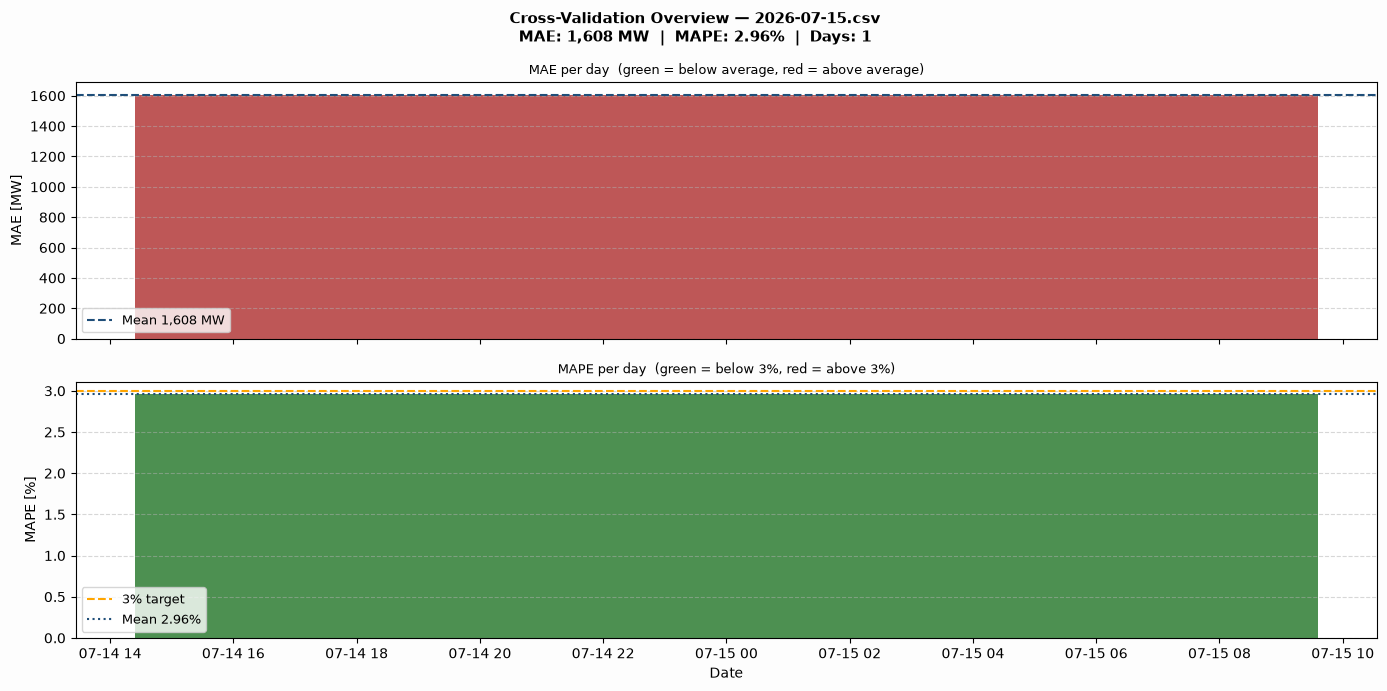

In [7]:
# ── Cell 7: Overview chart — MAE & MAPE per day ───────────────────────────────

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True, facecolor='#fdfdfd')
fig.suptitle(
    f'Cross-Validation Overview — {FORECAST_FILE.name}\n'
    f'MAE: {overall_mae:,.0f} MW  |  MAPE: {overall_mape:.2f}%  |  Days: {len(df_cv)}',
    fontsize=11, fontweight='bold',
)

dates = df_cv.index
colors_mae  = ['#2E7D32' if v < overall_mae  else '#B33A3A' for v in df_cv['mae_mw']]
colors_mape = ['#2E7D32' if v < 3.0          else '#B33A3A' for v in df_cv['mape_pct']]

ax1.bar(dates, df_cv['mae_mw'], color=colors_mae, alpha=0.85, width=0.8)
ax1.axhline(overall_mae, color='#1F4E79', linewidth=1.5, linestyle='--', label=f'Mean {overall_mae:,.0f} MW')
ax1.set_ylabel('MAE [MW]')
ax1.legend(fontsize=9)
ax1.grid(axis='y', linestyle='--', alpha=0.5)
ax1.set_title('MAE per day  (green = below average, red = above average)', fontsize=9)

ax2.bar(dates, df_cv['mape_pct'], color=colors_mape, alpha=0.85, width=0.8)
ax2.axhline(3.0, color='orange', linewidth=1.5, linestyle='--', label='3% target')
ax2.axhline(overall_mape, color='#1F4E79', linewidth=1.5, linestyle=':', label=f'Mean {overall_mape:.2f}%')
ax2.set_ylabel('MAPE [%]')
ax2.set_xlabel('Date')
ax2.legend(fontsize=9)
ax2.grid(axis='y', linestyle='--', alpha=0.5)
ax2.set_title('MAPE per day  (green = below 3%, red = above 3%)', fontsize=9)

if len(df_cv) > 1:
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    fig.autofmt_xdate(rotation=30)

plt.tight_layout()
plt.show()

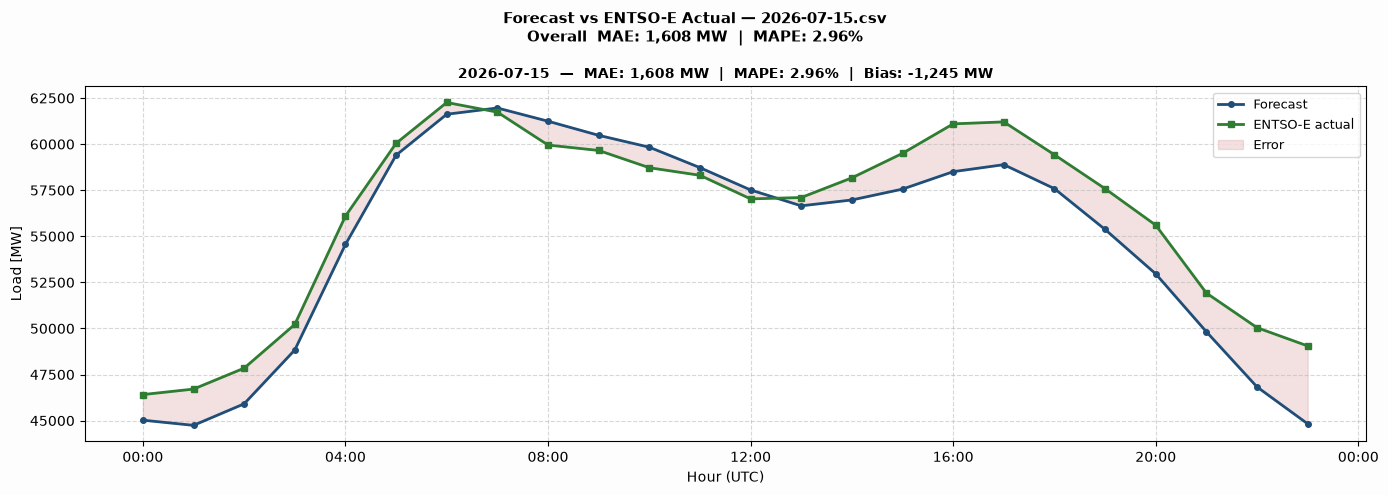

Showing: 2026-07-15  (change DETAIL_DATE above to view a different day)


In [8]:
# ── Cell 8: Detail plot — Forecast vs Actual for a chosen day ─────────────────
#
# Change DETAIL_DATE to any date in the scored range (or set to None for worst day)
# ─────────────────────────────────────────────────────────────────────────────
DETAIL_DATE = None   # e.g. '2026-07-06'  or None → worst-MAE day
# ─────────────────────────────────────────────────────────────────────────────

if DETAIL_DATE is None:
    focus = worst_day
else:
    focus = pd.Timestamp(DETAIL_DATE, tz='UTC')
    if focus not in df_cv.index:
        available = ', '.join(d.strftime('%Y-%m-%d') for d in df_cv.index)
        raise ValueError(f'{DETAIL_DATE} not scored. Available: {available}')

focus_str  = focus.strftime('%Y-%m-%d')
day_mask   = combined.index.normalize() == focus
day_data   = combined[day_mask]

day_mae  = df_cv.loc[focus, 'mae_mw']
day_mape = df_cv.loc[focus, 'mape_pct']
day_bias = df_cv.loc[focus, 'bias_mw']

fig, ax = plt.subplots(figsize=(14, 5), facecolor='#fdfdfd')
fig.suptitle(
    f'Forecast vs ENTSO-E Actual — {FORECAST_FILE.name}\n'
    f'Overall  MAE: {overall_mae:,.0f} MW  |  MAPE: {overall_mape:.2f}%',
    fontsize=11, fontweight='bold',
)

ax.plot(day_data.index, day_data['forecast_mw'],
        color='#1F4E79', linewidth=2, marker='o', markersize=4, label='Forecast')
ax.plot(day_data.index, day_data['actual_mw'],
        color='#2E7D32', linewidth=2, marker='s', markersize=4, label='ENTSO-E actual')
ax.fill_between(day_data.index, day_data['forecast_mw'], day_data['actual_mw'],
                alpha=0.15, color='#B33A3A', label='Error')

ax.set_title(
    f'{focus_str}  —  MAE: {day_mae:,.0f} MW  |  MAPE: {day_mape:.2f}%  |  Bias: {day_bias:+,.0f} MW',
    fontsize=10, fontweight='bold',
)
ax.set_xlabel('Hour (UTC)')
ax.set_ylabel('Load [MW]')
ax.legend(fontsize=9)
ax.grid(linestyle='--', alpha=0.5)
ax.xaxis.set_major_locator(mdates.HourLocator(byhour=[0, 4, 8, 12, 16, 20]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

plt.tight_layout()
plt.show()
print(f'Showing: {focus_str}  (change DETAIL_DATE above to view a different day)')

In [9]:
# ── Cell 9 (optional): Save results ──────────────────────────────────────────
#
# Set SAVE_RESULTS = True to write CSV + PNG to data/cross_validation/
# ─────────────────────────────────────────────────────────────────────────────
SAVE_RESULTS = False
# ─────────────────────────────────────────────────────────────────────────────

if SAVE_RESULTS:
    out_dir = REPO_ROOT / 'data' / 'cross_validation'
    out_dir.mkdir(parents=True, exist_ok=True)

    stem = FORECAST_FILE.stem  # e.g. '2026-07-06'

    csv_path = out_dir / f'cv_{stem}_summary.csv'
    df_cv.to_csv(csv_path)
    print(f'Saved CSV : {csv_path}')

    # Re-render the overview chart to a file
    fig2, (ax1b, ax2b) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
    fig2.suptitle(
        f'Cross-Validation — {FORECAST_FILE.name}\n'
        f'MAE: {overall_mae:,.0f} MW  |  MAPE: {overall_mape:.2f}%  |  Days: {len(df_cv)}',
        fontsize=11, fontweight='bold',
    )
    ax1b.bar(dates, df_cv['mae_mw'], color=colors_mae, alpha=0.85, width=0.8)
    ax1b.axhline(overall_mae, color='#1F4E79', linewidth=1.5, linestyle='--')
    ax1b.set_ylabel('MAE [MW]')
    ax1b.grid(axis='y', linestyle='--', alpha=0.5)

    ax2b.bar(dates, df_cv['mape_pct'], color=colors_mape, alpha=0.85, width=0.8)
    ax2b.axhline(3.0, color='orange', linewidth=1.5, linestyle='--')
    ax2b.set_ylabel('MAPE [%]')
    ax2b.set_xlabel('Date')
    ax2b.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()

    png_path = out_dir / f'cv_{stem}_overview.png'
    fig2.savefig(png_path, dpi=150, bbox_inches='tight')
    plt.close(fig2)
    print(f'Saved PNG : {png_path}')
else:
    print('SAVE_RESULTS = False  →  nothing written to disk.')

SAVE_RESULTS = False  →  nothing written to disk.
